# Agentic CGM demo (OhioT1DM-oriented)

Run from repo root with `PYTHONPATH=.`. Use synthetic data by default, or CSV/XML loaders for OhioT1DM exports (`timestamp`, `glucose`, optional `insulin`, `carbs`).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np

from src.agent.loop import AgentConfig, run_agent_on_series
from src.data.dataset import load_series

series = load_series("synthetic")
cfg = AgentConfig(ckpt_path=ROOT / "artifacts" / "lstm.pt")
traj, mem = run_agent_on_series(series, cfg, lookback=24, horizon=6)
print(f"steps={len(traj)} lstm_rate={np.mean([s.used_lstm for s in traj]):.2%}")

steps=1194 lstm_rate=69.01%


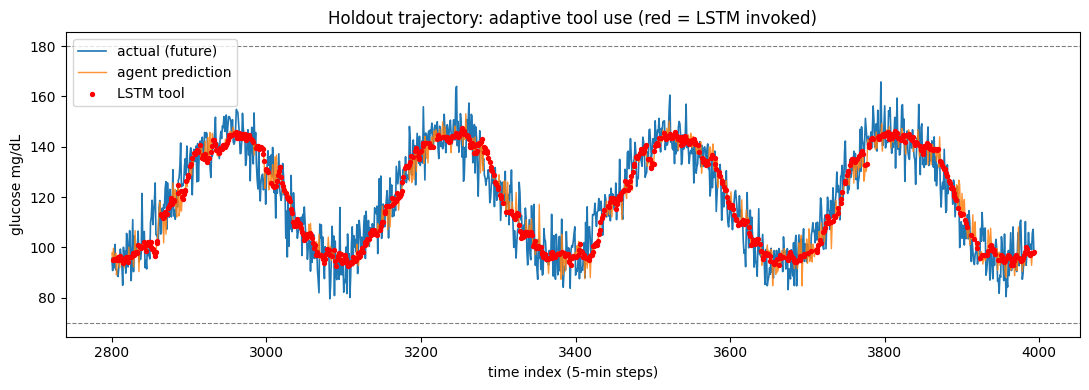

In [2]:
idx = np.array([s.t_index for s in traj])
pred = np.array([s.predicted_glucose for s in traj])
act = np.array([s.actual_glucose for s in traj])
used = np.array([s.used_lstm for s in traj], dtype=bool)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(idx, act, label="actual (future)", lw=1.2)
ax.plot(idx, pred, label="agent prediction", lw=1.0, alpha=0.85)
ax.scatter(idx[used], pred[used], s=8, c="red", label="LSTM tool", zorder=3)
ax.axhline(70, color="k", ls="--", lw=0.8, alpha=0.5)
ax.axhline(180, color="k", ls="--", lw=0.8, alpha=0.5)
ax.set_xlabel("time index (5-min steps)")
ax.set_ylabel("glucose mg/dL")
ax.legend()
ax.set_title("Holdout trajectory: adaptive tool use (red = LSTM invoked)")
plt.tight_layout()
plt.show()